In [20]:
import numpy as np
import pandas as pd

# The Task
To minimise the total number of respondents surveyed (our 'cost') by designing, implementing, and validating a policy or algorithm that determines **how to structure surveys before the month begins**.

This should define **how categories are allocated** to create **survey structures** that probabilistically achieve the desired outcomes while respecting the following constraints:

- Every category should receive roughly **200 qualified respondents** (we're modelling one month). In contracts, we specify that customers will receive at least 2,400 qualified respondents per year.
- The mean respondents should have a **total interview length of less than 480 seconds (8 minutes)**. This limit exists for two reasons:

1) to maintain data quality - we believe that respondent engagement starts to drop rapidly after an 8 minute survey - and,
2) because it's stipulated in our contractual agreement with our sample provider.

For simplicity, you may assume that the category qualifier consumes none of a respondent's time (0 seconds).However, note that in real-world implementation, there is a practical limit to how many qualifiers can be shown to a single respondent due to respondent burden and survey flow considerations.

While your solution may leverage the 0-second assumption, strong candidates will consider **how their approach would translate to real-world constraints**.

The demographic distribution of the sample exposed to each category's qualifiers should match that of the national population (At Tracksuit, we quota for at least the gender, age, and region variables). We require this to avoid respondent bias and maintain best-in-class research practice.

In [21]:
# Load data table & print summary stats
data = pd.read_csv('/Users/irene/Documents/tracksuit-test/fake_category_data.csv')
print(data.describe().round(2))
data.head()

       category_id  incidence_rate  category_length_seconds
count        77.00           77.00                    77.00
mean         39.97            0.47                   108.80
std          22.42            0.20                    40.64
min           1.00            0.10                    32.01
25%          21.00            0.31                    79.86
50%          40.00            0.43                   104.65
75%          59.00            0.62                   145.48
max          78.00            0.89                   178.79


,category_id,category_name,incidence_rate,category_length_seconds
0,1,Fertility or IVF service,0.095621,164.504580
1,2,Big and Tall Men's Clothing,0.131231,69.826299
2,4,Self Tan (Female Only),0.191096,115.928005
3,5,Baby Feeding,0.198451,166.231168
4,6,Baby products,0.188133,60.252290


In [22]:
demo = pd.read_csv('/Users/irene/Documents/tracksuit-test/Age-sex-by-ethnic-group-grouped-total-responses-census-usually-resident-population-counts-2006-2013-2018-Censuses-RC-TA-SA2-DHB/Data8277.csv', low_memory=False)
print('Demo table shape', demo.shape)
demo.head()

Demo table shape (34959672, 6)


,Year,Age,Ethnic,Sex,Area,count
0,2018,0,1,1,01,795
1,2018,0,1,1,02,5067
2,2018,0,1,1,03,2229
3,2018,0,1,1,04,1356
4,2018,0,1,1,05,180


In [23]:
# Required exposures: how many people must see each qualifier
data['required_exposures'] = np.ceil(200 / data['incidence_rate'])

# Expected respondent burden per category
data['expected_time'] = data['incidence_rate'] * data['category_length_seconds']

# Sort by expected burden
data = data.sort_values('expected_time', ascending=False) # for greedy packing

# Greedy construction of survey groups with expected time < 480s
survey_groups = []
for _, row in data.iterrows():
    placed = False
    for survey in survey_groups:
        current_time = survey['expected_time']
        if current_time + row['expected_time'] <= 480:
            survey['categories'].append(row['category_id'])
            survey['expected_time'] += row['expected_time']
            placed = True
            break
    if not placed:
        survey_groups.append({'categories': [row['category_id']],
                              'expected_time': row['expected_time']})

# Inspect survey structure
survey_summary = pd.DataFrame({'survey_id': range(len(survey_groups)),
                               'n_categories': [len(s['categories']) for s in survey_groups],
                               'expected_time': [s['expected_time'] for s in survey_groups]})
print(survey_summary)

   survey_id  n_categories  expected_time
0          0             4     473.214937
1          1             5     479.084727
2          2             6     477.063507
3          3             8     479.661322
4          4             8     479.615011
5          5            10     479.428657
6          6            12     476.843033
7          7            18     475.840367
8          8             6      79.177806


In [24]:
# Prepare lookup for simulation
category_lookup = data.set_index('category_id').to_dict('index')

# Precompute required exposures per category
required_exposures = dict(zip(data['category_id'], data['required_exposures']))

# Simulation: track exposures + qualified completes
exposure_counts = {cid: 0 for cid in data['category_id']}
qualified_counts = {cid: 0 for cid in data['category_id']}
respondent_times = []

# Compute how many respondents each version needs (version weights)
version_probs = np.array([len(s['categories']) for s in survey_groups])
version_probs = version_probs / version_probs.sum()

# Simulation loop
# Continue until all categories reach required exposures
while any(exposure_counts[cid] < required_exposures[cid] for cid in exposure_counts):

    # Randomly choose a survey version proportional to required size
    v_idx = np.random.choice(len(survey_groups), p=version_probs)
    survey = survey_groups[v_idx]

    total_time = 0

    for cid in survey['categories']:
        exposure_counts[cid] += 1

        # Simulate qualification
        if np.random.rand() < category_lookup[cid]['incidence_rate']:
            total_time += category_lookup[cid]['category_length_seconds']
            qualified_counts[cid] += 1

    respondent_times.append(total_time)

# Total respondents required
n_respondents = len(respondent_times)

# Validation metrics
mean_time = np.mean(respondent_times)
p95_time = np.percentile(respondent_times, 95)
max_time = np.max(respondent_times)

print('Mean interview length:', round(mean_time, 2))
print('95th percentile:', round(p95_time, 2))
print('Maximum observed:', round(max_time, 2))

results = pd.DataFrame({'category_id': list(qualified_counts.keys()), 'qualified_respondents': list(qualified_counts.values())})
results = results.merge(data[['category_id', 'category_name']], on='category_id')
results['met_target'] = results['qualified_respondents'] >= 200

print(results.head())
counts = results['met_target'].value_counts()
print('Categories meeting target:', counts.get(True, 0))
print('Categories not meeting target:', counts.get(False, 0))
print('Total respondents required:', n_respondents)

total_qualified = results['qualified_respondents'].sum()
efficiency = total_qualified / n_respondents
print('Qualified completes per respondent:', round(efficiency, 2))

Mean interview length: 445.28
95th percentile: 743.83
Maximum observed: 1188.93
   category_id  qualified_respondents              category_name  met_target
0           69                   1137          Healthy Beverages        True
1           71                   1049    Chocolate confectionery        True
2           77                   1027  Breakfast or Health Foods        True
3           73                   1287          Wealth Management        True
4           66                   1375                  Chocolate        True
Categories meeting target: 77
Categories not meeting target: 0
Total respondents required: 26064
Qualified completes per respondent: 4.51


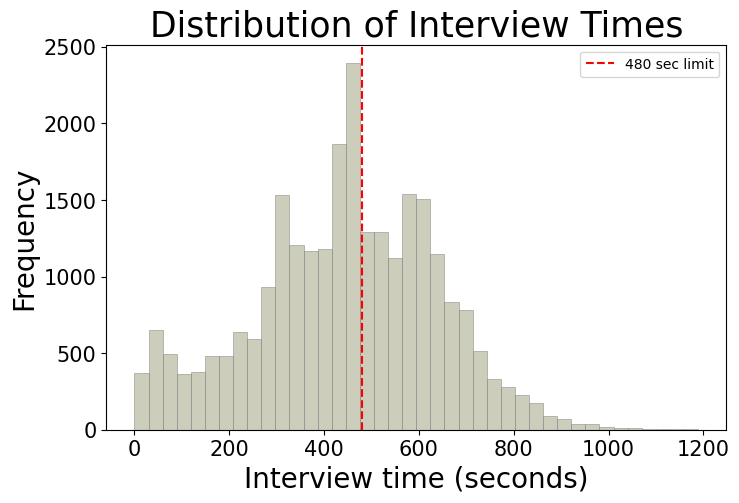

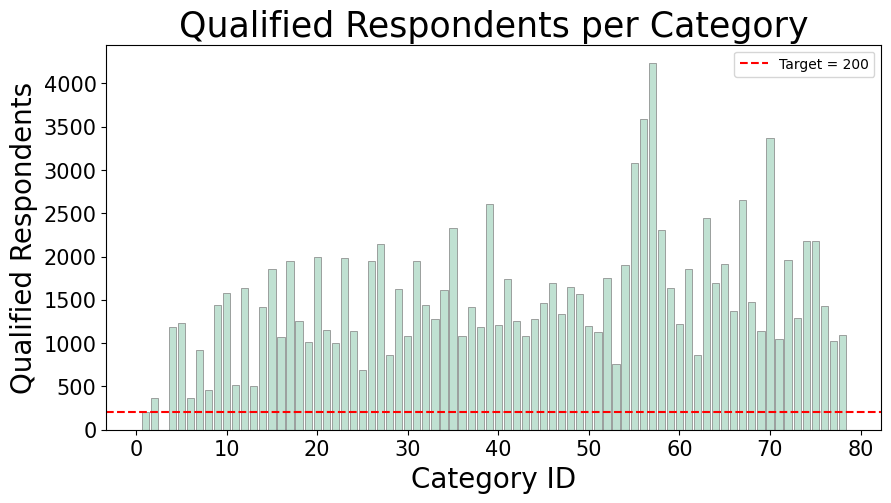

In [25]:
# Plots
import matplotlib.pyplot as plt

# Histogram of interview times
plt.figure(figsize=(8,5))
plt.hist(respondent_times, bins=40, color='#B7B89F', alpha=0.7, edgecolor='grey', linewidth=0.5)
plt.axvline(480, color='red', linestyle='--', label='480 sec limit')
plt.title('Distribution of Interview Times', fontsize=25)
plt.xlabel('Interview time (seconds)', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()

# Exposure counts per category
plt.figure(figsize=(10,5))
plt.bar(results['category_id'], results['qualified_respondents'], color='#C0E1D2', edgecolor='grey', linewidth=0.5)
plt.axhline(200, color='red', linestyle='--', label='Target = 200')
plt.title('Qualified Respondents per Category', fontsize=25)
plt.xlabel('Category ID', fontsize=20)
plt.ylabel('Qualified Respondents', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()


In [ ]:
# Illustrative demographic modelling for exposure simulation: how demographics *could* be incorporate into the simulation if required
# Define demographic cells
age_groups = np.array(['18-24', '25-34', '35-44', '45-54', '55+'])

# Equal probability for each age band
age_probs = np.ones(len(age_groups)) / len(age_groups)

# Alternative: use national proportions
# demo_2018 = demo[(demo['Year'] == 2018) & (demo['Age'] >= 18)].copy()
# bins = [18, 24, 34, 44, 54, 200]
# labels = age_groups
# demo_2018['age_group'] = pd.cut(demo_2018['Age'], bins=bins, labels=labels)
# age_counts = demo_2018.groupby('age_group')['count'].sum()
# age_probs = (age_counts / age_counts.sum()).values

# Sample a demographic label for each respondent
n = 5000
demo_sample = np.random.choice(age_groups, size=n, p=age_probs)

# Assign respondents to survey versions, independent of demo
version_probs = np.ones(len(survey_groups)) / len(survey_groups)
assigned_versions = np.random.choice(len(survey_groups), size=n, p=version_probs)

# Track category exposures by demographic group
exposures_by_demo = []

for i in range(n):
    version = survey_groups[assigned_versions[i]]
    demo_label = demo_sample[i]
    for cid in version['categories']:
        exposures_by_demo.append((cid, demo_label))

exposures_df = pd.DataFrame(exposures_by_demo, columns=['category_id', 'demo'])

# Compare exposure distribution for an example category
example_cat = exposures_df['category_id'].iloc[0]
print('Exposure distribution for category:', example_cat)
print(exposures_df[exposures_df['category_id'] == example_cat]['demo'].value_counts(normalize=True))
print('\nUnderlying demographic distribution:')
print(pd.Series(age_probs, index=age_groups))

Exposure distribution for category: 38
demo
18-24    0.234676
45-54    0.217163
35-44    0.194396
25-34    0.187391
55+      0.166375
Name: proportion, dtype: float64

Underlying demographic distribution:
18-24    0.2
25-34    0.2
35-44    0.2
45-54    0.2
55+      0.2
dtype: float64
